# Can a spam filter be worth 67 million parameters?

AT&T flags spam SMS by hand and wants that automated. The brief asks for a deep learning model
that decides, from the text alone, whether a message is spam — and it gives two hints: *start
simple*, and *transfer learning might help*.

This notebook takes both hints literally and measures them. Three models are trained on the same
5 169 messages and scored the same way:

| | what it is | parameters |
|---|---|---|
| **Reference** | TF-IDF on character n-grams + a linear SVM — not deep learning at all | a matrix |
| **From scratch** | an embedding layer + a bidirectional LSTM, learned from these messages only | 0.6 M |
| **Transfer** | `distilbert-base-uncased`, pretrained on 3 billion words, fine-tuned here | 67 M |

---

### How this notebook is organised

| Section | What it does |
|---|---|
| 1 | Load the file — including the 50 messages the usual fix silently truncates |
| 2 | Fix the evaluation protocol before training anything: duplicates, metric, and what each choice costs |
| 3 | What a spam SMS looks like — and how far its *shape* alone gets you |
| 4 | The reference model: the number the neural networks have to beat |
| 5 | Deep learning from scratch |
| 6 | Transfer learning: fine-tuning DistilBERT |
| 7 | The comparison, over five seeds — score, errors, threshold |
| 8 | What AT&T should deploy |

Every claim below is the output of the cell above it. The notebook runs on a GPU in about four
minutes (about twenty on a CPU) and downloads the DistilBERT weights on first run.

## 1. The file

In [1]:
import logging
import os
import time
import warnings
from collections import Counter
from pathlib import Path

# Both must be set before transformers is imported: the hub prints a download bar and a notice
# about unauthenticated requests, six times each, around output that matters.
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import torch
import torch.nn as nn
import transformers
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Plotly figures are rendered as static images rather than interactive widgets.
# Reason: this notebook is the deliverable and has to stay readable wherever it is opened.
# GitHub, nbviewer and PDF exports all strip interactive plotly output and would show nothing.
pio.renderers.default = 'png'

IMAGES = Path('images')
IMAGES.mkdir(exist_ok=True)

# One seed for the whole notebook: the splits, the weight initialisations and the shuffling of
# every batch read it. GPU kernels are still not bit-deterministic, so a re-run moves the third
# decimal of a single model; section 7 is built around that fact rather than against it.
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BLUE, RED, GREY = '#2a78d6', '#e34948', '#8a8a85'

warnings.filterwarnings('ignore', category=FutureWarning)

# transformers prints a load report every time a checkpoint is read -- six times in this notebook,
# all identical. It says the classification head is newly initialised, which is what fine-tuning
# means and is stated in section 6; silenced here so it does not bury the output it precedes.
transformers.logging.set_verbosity_error()


def show(fig, name, height=520):
    """Render a figure in the notebook and save it as a PNG under images/."""
    fig.update_layout(width=980, height=height, template='plotly_white',
                      margin=dict(t=80, b=60, l=70, r=40))
    fig.write_image(IMAGES / f'{name}.png', scale=2)
    fig.show()


print(f'torch {torch.__version__} on {DEVICE}'
      + (f' ({torch.cuda.get_device_name(0)})' if DEVICE == 'cuda' else ''))

torch 2.13.0+cu130 on cuda (NVIDIA GeForce RTX 3090 Ti)


In [2]:
# encoding='latin-1': the file is not UTF-8 -- it carries raw pound signs and smart quotes from
# the original SMS collection, and utf-8 refuses to decode them.
raw = pd.read_csv('data/spam.csv', encoding='latin-1')

print(f'{raw.shape[0]} rows x {raw.shape[1]} columns: {list(raw.columns)}')
print(f'\nnon-null values per column:\n{raw.notna().sum().to_string()}')
raw.head(3)

5572 rows x 5 columns: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

non-null values per column:
v1            5572
v2            5572
Unnamed: 2      50
Unnamed: 3      12
Unnamed: 4       6


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN


### 1.1 The three unnamed columns are not empty — they are the end of 50 messages

`v1` is the label and `v2` is the message. The three `Unnamed` columns look like the debris every
tutorial drops on the first line. They are not debris: the file is a CSV of unescaped text, so
**every message containing a comma inside a quote was split across the extra columns.**

Dropping them does not remove noise, it truncates messages — and it truncates them *in the middle
of the evidence*, since the tail of a spam SMS is where the phone number and the price live.

In [3]:
EXTRA = ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
split_rows = raw[EXTRA].notna().any(axis=1)

# Put the message back together in the order the commas broke it.
text = raw.apply(lambda r: ','.join([str(r['v2'])] + [str(r[c]) for c in EXTRA if pd.notna(r[c])]),
                 axis=1)
messages = pd.DataFrame({'label': (raw['v1'] == 'spam').astype(int), 'text': text})

print(f'messages split across the extra columns : {split_rows.sum()}')
print(f'their mean length, truncated            : {raw.loc[split_rows, "v2"].str.len().mean():.0f} characters')
print(f'their mean length, put back together    : {text[split_rows].str.len().mean():.0f} characters')
print(f'\nexample, truncated : ...{raw.loc[split_rows, "v2"].iloc[0][-70:]}')
print(f'example, repaired  : ...{text[split_rows].iloc[0][-70:]}')

messages split across the extra columns : 50
their mean length, truncated            : 92 characters
their mean length, put back together    : 156 characters

example, truncated : ...ext the password \MIX\" to 85069 to verify. Get Usher and Britney. FML
example, repaired  : ... verify. Get Usher and Britney. FML, PO Box 5249, MK17 92H. 450Ppw 16"


**Forty per cent of the text of those messages was being thrown away** — 92 characters kept out
of 156, on 50 messages out of 5 572. A spam filter that never sees the end of a spam is not the
thing AT&T asked for.

In [4]:
print(messages['label'].value_counts().rename({0: 'ham', 1: 'spam'}).to_string())
print(f'\nspam rate: {messages["label"].mean():.2%}')

label
ham     4825
spam     747

spam rate: 13.41%


**The classes are imbalanced: 747 spam against 4 825 ham.** Every split in this notebook will be
stratified on the label, so that train and test keep the same spam rate.

## 2. The evaluation protocol, decided before anything is trained

Two properties of this file decide what a score means. Both are settled here, so that every number
in sections 4 to 7 is comparable.

### 2.1 The same message appears many times, and a naive split puts it on both sides

In [5]:
dups = messages['text'].duplicated().sum()
repeated = messages[messages['text'].duplicated(keep=False)]
print(f'exactly duplicated messages : {dups} of {len(messages)}')
print(f'rows involved               : {len(repeated)}, covering {repeated["text"].nunique()} distinct texts')
print(f'texts carrying both labels  : {(messages.groupby("text")["label"].nunique() > 1).sum()}')
print(f'\nmost repeated messages:\n{messages["text"].value_counts().head(3).to_string()}')

# What a naive split does with them.
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    messages['text'], messages['label'], test_size=0.2, random_state=RANDOM_STATE,
    stratify=messages['label'])
seen = Xn_te.isin(set(Xn_tr))
naive = Pipeline([('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2)),
                  ('svm', LinearSVC())]).fit(Xn_tr, yn_tr)
pred = naive.predict(Xn_te)
print(f'\ntest messages already present in the training set : {seen.sum()} / {len(Xn_te)} ({seen.mean():.1%})')
print(f'  f1 on those                                    : {f1_score(yn_te[seen], pred[seen]):.4f}')
print(f'  f1 on the messages the model has never seen    : {f1_score(yn_te[~seen], pred[~seen]):.4f}')

exactly duplicated messages : 403 of 5572
rows involved               : 684, covering 281 distinct texts
texts carrying both labels  : 0

most repeated messages:
text
Sorry, I'll call later                                 30
I cant pick the phone right now. Pls send a message    12
Ok...                                                  10



test messages already present in the training set : 129 / 1115 (11.6%)
  f1 on those                                    : 1.0000
  f1 on the messages the model has never seen    : 0.9561


**One test message in nine is a copy of a training message**, and the model is perfect on them —
it is being graded on its memory, not on its ability to catch a spam it has never met.

So the messages are deduplicated **before** the split. What is measured from here on is the only
thing worth deploying: catching a *new* spam. (In production the duplicates are free anyway — an
exact-match cache handles a repeated campaign without any model at all.)

In [6]:
data = messages.drop_duplicates(subset=['text']).reset_index(drop=True)
X_train, X_test, y_train, y_test = train_test_split(
    data['text'], data['label'], test_size=0.2, random_state=RANDOM_STATE, stratify=data['label'])

print(f'{len(messages)} messages -> {len(data)} after deduplication  (spam rate {data["label"].mean():.2%})')
print(f'train {len(X_train)}   test {len(X_test)}  ({int(y_test.sum())} spam in the test set)')

5572 messages -> 5169 after deduplication  (spam rate 12.63%)
train 4135   test 1034  (131 spam in the test set)


### 2.2 The metric

**13% of the messages are spam.** A model that answers "ham" to everything is right 87% of the
time, so accuracy is not a metric here. Every score below is the **f1-score of the spam class** —
the harmonic mean of precision (of the messages we block, how many were really spam) and recall
(of the spams sent, how many we blocked) — which that model scores 0 on.

The two errors are not symmetric for a carrier, and the notebook keeps them separate throughout:
a **false negative** is a spam that reaches the customer; a **false positive** is a real message
from a real person that AT&T withheld.

In [7]:
print(f'the "nothing is spam" model: accuracy {1 - y_test.mean():.1%}, '
      f'f1 {f1_score(y_test, np.zeros(len(y_test))):.3f}')

the "nothing is spam" model: accuracy 87.3%, f1 0.000


### 2.3 What the two protocol decisions cost

In [8]:
truncated = pd.DataFrame({'label': (raw['v1'] == 'spam').astype(int), 'text': raw['v2']})

def protocol_f1(frame, dedupe):
    """The reference model of section 4, trained and scored under one protocol."""
    df = frame.drop_duplicates(subset=['text']) if dedupe else frame
    a, b, c, d = train_test_split(df['text'], df['label'], test_size=0.2,
                                  random_state=RANDOM_STATE, stratify=df['label'])
    p = Pipeline([('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2)),
                  ('svm', LinearSVC())]).fit(a, c).predict(b)
    tn, fp, fn, tp = confusion_matrix(d, p).ravel()
    return {'messages': len(df), 'f1': f1_score(d, p), 'false alarms': fp, 'spam missed': fn}

print(pd.DataFrame({
    'repaired + deduplicated (this notebook)': protocol_f1(messages, True),
    'truncated + deduplicated':                protocol_f1(truncated, True),
    'repaired, duplicates kept':               protocol_f1(messages, False),
    'truncated, duplicates kept':              protocol_f1(truncated, False),
}).T.round(4).to_string())

                                         messages      f1  false alarms  spam missed
repaired + deduplicated (this notebook)    5169.0  0.9644           0.0          9.0
truncated + deduplicated                   5169.0  0.9685           0.0          8.0
repaired, duplicates kept                  5572.0  0.9653           0.0         10.0
truncated, duplicates kept                 5572.0  0.9689           0.0          9.0


The four protocols land within **0.005 of f1** of each other — less than the spread between two
random seeds measured in section 7. Neither decision is worth a point of score, and that is the
honest reading: **they change what the number means, not what it is.** Repairing the messages buys
integrity, deduplicating buys a score that is about generalisation. Both are kept for that reason,
and the notebook does not pretend either one bought performance.

## 3. What a spam SMS looks like

In [9]:
data = data.assign(
    length=data['text'].str.len(),
    words=data['text'].str.split().str.len(),
    digits=data['text'].str.count(r'\d'),
    uppercase=data['text'].str.count(r'[A-Z]') / data['text'].str.len().clip(lower=1),
)
print(data.groupby('label')[['length', 'words', 'digits', 'uppercase']]
      .agg(['mean', 'std']).round(2).rename(index={0: 'ham', 1: 'spam'}).to_string())

       length         words        digits       uppercase      
         mean    std   mean    std   mean   std      mean   std
label                                                          
ham     71.06  56.71  14.24  11.17   0.30  1.02      0.06  0.11
spam   138.17  29.92  23.74   5.93  15.49  8.90      0.11  0.09


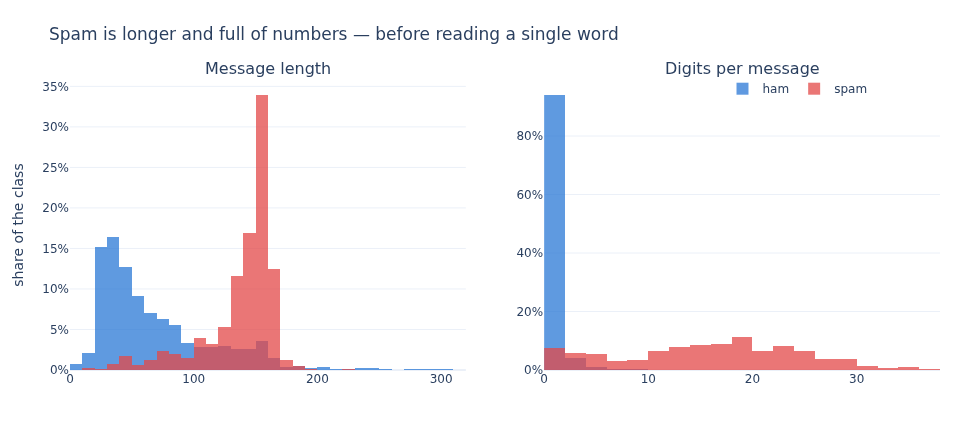

In [10]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=('Message length', 'Digits per message'))
for value, name, color in [(0, 'ham', BLUE), (1, 'spam', RED)]:
    sub = data[data['label'] == value]
    fig.add_trace(go.Histogram(x=sub['length'], name=name, marker_color=color, opacity=0.75,
                               xbins=dict(start=0, end=320, size=10), histnorm='probability'),
                  row=1, col=1)
    fig.add_trace(go.Histogram(x=sub['digits'], name=name, marker_color=color, opacity=0.75,
                               xbins=dict(start=0, end=40, size=2), histnorm='probability',
                               showlegend=False), row=1, col=2)
fig.update_layout(barmode='overlay', title='Spam is longer and full of numbers — before reading a single word',
                  legend=dict(orientation='h', y=1.02, x=0.75))
fig.update_yaxes(title='share of the class', tickformat='.0%', row=1, col=1)
fig.update_yaxes(tickformat='.0%', row=1, col=2)
show(fig, '1_shape_of_a_spam', height=430)

A spam SMS is **138 characters long against 71 for a real message**, and its length varies far
less: these messages are written to fill the 160-character limit, and a human text stops when the
sentence stops. They carry **15 digits on average against 0.3** — phone numbers, short codes,
prices, expiry dates.

None of that is language. The next cell asks how far it gets on its own.

In [11]:
# Four numbers per message, no words at all: length, word count, digit count, uppercase ratio.
SHAPE = ['length', 'words', 'digits', 'uppercase']
shape_model = Pipeline([('scale', StandardScaler()),
                        ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
shape_model.fit(data.loc[X_train.index, SHAPE], y_train)
shape_pred = shape_model.predict(data.loc[X_test.index, SHAPE])
tn, fp, fn, tp = confusion_matrix(y_test, shape_pred).ravel()
print(f'shape only (no words)   f1 {f1_score(y_test, shape_pred):.4f}   '
      f'false alarms {fp}   spam missed {fn}')

shape only (no words)   f1 0.8602   false alarms 28   spam missed 11


**f1 = 0.86 without reading a word.** Four counts and a logistic regression catch **92% of the
spam** — at the price of withholding 28 real messages, which section 2.2 already said is the
expensive error. That is the floor this project sits on: everything the rest of the notebook does —
character n-grams, an LSTM, a pretrained transformer — is spent on the last 8% and on those 28
false alarms.

## 4. The reference — not deep learning

The brief asks for a neural network, and the honest way to grant that request is to put a number
next to it that a neural network has to beat. **TF-IDF on character n-grams of 2 to 5, then a
linear SVM.** Character n-grams rather than words because SMS spam is written to defeat word
filters — `FR33`, `W1NNER`, `txt`, `cl4im` — and a character window catches what a vocabulary of
words misses.

In [12]:
reference = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2)),
    ('svm', LinearSVC()),
])
t0 = time.time()
reference.fit(X_train, y_train)
reference_seconds = time.time() - t0
reference_pred = reference.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, reference_pred).ravel()

print(f'features        : {len(reference.named_steps["tfidf"].vocabulary_):,} character n-grams')
print(f'training time   : {reference_seconds:.1f} s on one CPU core')
print(f'f1              : {f1_score(y_test, reference_pred):.4f}')
print(f'precision {tp / (tp + fp):.3f}   recall {tp / (tp + fn):.3f}   '
      f'false alarms {fp}   spam missed {fn}')

features        : 33,039 character n-grams
training time   : 0.8 s on one CPU core
f1              : 0.9644
precision 1.000   recall 0.931   false alarms 0   spam missed 9


**f1 = 0.96, in under a second, with zero false alarms.** This is the bar.

## 5. Deep learning, from scratch

The first hint in the brief is *start simple*. The simplest network that reads a sequence: an
embedding layer that learns a 64-dimension vector per word, a bidirectional LSTM that reads the
message in both directions, max-pooling over time, and a classifier.

Everything it knows about English, it has to learn from **4 135 training messages.**

In [13]:
MAX_LEN, VOCAB_SIZE = 60, 6_000


def tokenize(s):
    return s.lower().split()


def build_vocab(texts):
    """Index 0 is padding, index 1 is the unknown word."""
    counts = Counter(w for s in texts for w in tokenize(s))
    return {w: i + 2 for i, (w, _) in enumerate(counts.most_common(VOCAB_SIZE - 2))}, len(counts)


def encode(texts, vocab):
    ids = np.zeros((len(texts), MAX_LEN), dtype=np.int64)
    for i, s in enumerate(texts):
        seq = [vocab.get(w, 1) for w in tokenize(s)][:MAX_LEN]
        ids[i, :len(seq)] = seq
    return torch.tensor(ids)


class BiLSTM(nn.Module):
    def __init__(self, dim=64, hidden=64, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, dim, padding_idx=0)
        self.lstm = nn.LSTM(dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(2 * hidden, 2)

    def forward(self, ids):
        sequence, _ = self.lstm(self.embedding(ids))
        return self.head(self.dropout(sequence.max(dim=1).values))


def train(model, loader, epochs, lr):
    """The same loop trains both networks in this notebook."""
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    t0 = time.time()
    for _ in range(epochs):
        for batch in loader:
            batch = [b.to(DEVICE) for b in batch]
            optimiser.zero_grad()
            loss_fn(model(*batch[:-1]), batch[-1]).backward()
            optimiser.step()
    return time.time() - t0


@torch.no_grad()
def predict(model, loader):
    model.eval()
    return torch.cat([model(*[b.to(DEVICE) for b in batch][:-1]).argmax(1).cpu()
                      for batch in loader]).numpy()


def lstm_loader(texts, labels, vocab, batch_size, shuffle=False):
    return DataLoader(TensorDataset(encode(texts, vocab), torch.tensor(labels.values)),
                      batch_size=batch_size, shuffle=shuffle)

In [14]:
# The network's size and training length are chosen on a validation split carved out of the
# TRAINING half -- reading them off the test set would be tuning on the score we report.
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train)
vocab, seen_words = build_vocab(X_fit)
print(f'vocabulary: {len(vocab):,} words kept of {seen_words:,} seen in the training half\n')

val_loader = lstm_loader(X_val, y_val, vocab, 64)
for dim, hidden, epochs in [(32, 32, 4), (64, 64, 3), (64, 64, 6), (64, 64, 10),
                            (128, 128, 6), (64, 128, 8)]:
    torch.manual_seed(RANDOM_STATE)
    model = BiLSTM(dim, hidden).to(DEVICE)
    train(model, lstm_loader(X_fit, y_fit, vocab, 32, shuffle=True), epochs, 1e-3)
    print(f'  embedding {dim:3d}  hidden {hidden:3d}  epochs {epochs:2d}   '
          f'validation f1 {f1_score(y_val, predict(model, val_loader)):.4f}')

vocabulary: 5,998 words kept of 10,038 seen in the training half



  embedding  32  hidden  32  epochs  4   validation f1 0.8351


  embedding  64  hidden  64  epochs  3   validation f1 0.8720


  embedding  64  hidden  64  epochs  6   validation f1 0.8404


  embedding  64  hidden  64  epochs 10   validation f1 0.8945


  embedding 128  hidden 128  epochs  6   validation f1 0.8660


  embedding  64  hidden 128  epochs  8   validation f1 0.9064


The sweep picks the largest and longest-trained of the six — **embedding 64, hidden 128, 8
epochs** — which is already a signal: the network is data-starved, not capacity-starved. It is
retrained below on the full training half and scored on the test set.

In [15]:
DIM, HIDDEN, EPOCHS = 64, 128, 8
vocab_full, _ = build_vocab(X_train)
torch.manual_seed(RANDOM_STATE)
scratch = BiLSTM(DIM, HIDDEN).to(DEVICE)
scratch_seconds = train(scratch, lstm_loader(X_train, y_train, vocab_full, 32, shuffle=True),
                        EPOCHS, 1e-3)
scratch_pred = predict(scratch, lstm_loader(X_test, y_test, vocab_full, 64))
tn, fp, fn, tp = confusion_matrix(y_test, scratch_pred).ravel()

print(f'parameters      : {sum(p.numel() for p in scratch.parameters()):,}')
print(f'training time   : {scratch_seconds:.1f} s on {DEVICE}')
print(f'f1              : {f1_score(y_test, scratch_pred):.4f}')
print(f'precision {tp / (tp + fp):.3f}   recall {tp / (tp + fn):.3f}   '
      f'false alarms {fp}   spam missed {fn}')

parameters      : 583,170
training time   : 4.3 s on cuda
f1              : 0.8871
precision 0.940   recall 0.840   false alarms 7   spam missed 21


**The neural network loses to the linear model**, and not narrowly. Section 7 repeats both over
five seeds before that sentence is allowed to stand, but the reason is already visible in the
sweep: 600 000 parameters, of which 384 000 are an embedding table, are being asked to learn what
English words mean from four thousand text messages. There is not enough language in this file to
learn a language.

Which is exactly the situation the brief's second hint is about.

## 6. Transfer learning — fine-tuning DistilBERT

`distilbert-base-uncased` has already read about 3 billion words of English. It arrives knowing
that *free* and *complimentary* are related, that a string of digits is a phone number, and that
`txt` is a verb. Fine-tuning replaces its output head and nudges all 67 million weights for three
passes over the same 4 135 messages.

The training loop is the one from section 5, unchanged — only the model and the tokeniser differ.

In [16]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class DistilBERT(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    def forward(self, ids, mask):
        return self.model(input_ids=ids, attention_mask=mask).logits


def bert_loader(texts, labels, batch_size, shuffle=False):
    # max_length=64 word pieces covers the longest message in the file with room to spare.
    encoded = tokenizer(list(texts), truncation=True, max_length=64, padding='max_length',
                        return_tensors='pt')
    return DataLoader(TensorDataset(encoded['input_ids'], encoded['attention_mask'],
                                    torch.tensor(labels.values)),
                      batch_size=batch_size, shuffle=shuffle)


torch.manual_seed(RANDOM_STATE)
bert = DistilBERT().to(DEVICE)
bert_seconds = train(bert, bert_loader(X_train, y_train, 32, shuffle=True), 3, 3e-5)
bert_pred = predict(bert, bert_loader(X_test, y_test, 64))
tn, fp, fn, tp = confusion_matrix(y_test, bert_pred).ravel()

print(f'parameters      : {sum(p.numel() for p in bert.parameters()):,}')
print(f'training time   : {bert_seconds:.1f} s on {DEVICE}')
print(f'f1              : {f1_score(y_test, bert_pred):.4f}')
print(f'precision {tp / (tp + fp):.3f}   recall {tp / (tp + fn):.3f}   '
      f'false alarms {fp}   spam missed {fn}')

parameters      : 66,955,010
training time   : 23.2 s on cuda
f1              : 0.9513
precision 0.934   recall 0.969   false alarms 9   spam missed 4


Six points of f1 above the network trained from scratch, on the same messages, with the same loop
and the same seed. **The gain comes from the pretraining, not from the depth** — the two networks
have comparable architectures in kind; only one of them arrived already knowing English.

Against the linear reference, the comparison is close enough that a single split cannot settle it.
That is section 7.

## 7. The comparison that actually decides

### 7.1 Five seeds

One test split holds 131 spam messages, so a difference of two messages moves the f1 by half a
point. The whole procedure — split, train, score — is repeated five times below, which is what a
claim about one model beating another has to survive.

In [17]:
records = []
for seed in range(5):
    Xa, Xb, ya, yb = train_test_split(data['text'], data['label'], test_size=0.2,
                                      random_state=seed, stratify=data['label'])

    ref = Pipeline([('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2)),
                    ('svm', LinearSVC())]).fit(Xa, ya)
    predictions = {'TF-IDF + linear SVM': ref.predict(Xb)}

    vocab_seed, _ = build_vocab(Xa)
    torch.manual_seed(seed)
    net = BiLSTM(DIM, HIDDEN).to(DEVICE)
    train(net, lstm_loader(Xa, ya, vocab_seed, 32, shuffle=True), EPOCHS, 1e-3)
    predictions['BiLSTM from scratch'] = predict(net, lstm_loader(Xb, yb, vocab_seed, 64))

    torch.manual_seed(seed)
    tuned = DistilBERT().to(DEVICE)
    train(tuned, bert_loader(Xa, ya, 32, shuffle=True), 3, 3e-5)
    predictions['DistilBERT fine-tuned'] = predict(tuned, bert_loader(Xb, yb, 64))

    for name, p in predictions.items():
        tn, fp, fn, tp = confusion_matrix(yb, p).ravel()
        records.append({'seed': seed, 'model': name, 'f1': f1_score(yb, p),
                        'false alarms': fp, 'spam missed': fn})
    print(f'  seed {seed} done')

seeds = pd.DataFrame(records)
ORDER = ['TF-IDF + linear SVM', 'BiLSTM from scratch', 'DistilBERT fine-tuned']
summary = seeds.groupby('model').agg(**{
    'f1 mean': ('f1', 'mean'), 'f1 std': ('f1', 'std'),
    'false alarms': ('false alarms', 'mean'), 'spam missed': ('spam missed', 'mean'),
}).reindex(ORDER)
print()
print(summary.round(4).to_string())

  seed 0 done


  seed 1 done


  seed 2 done


  seed 3 done


  seed 4 done

                       f1 mean  f1 std  false alarms  spam missed
model                                                            
TF-IDF + linear SVM     0.9603  0.0139           0.4          9.6
BiLSTM from scratch     0.9043  0.0272           7.6         16.6
DistilBERT fine-tuned   0.9601  0.0056           4.2          6.2


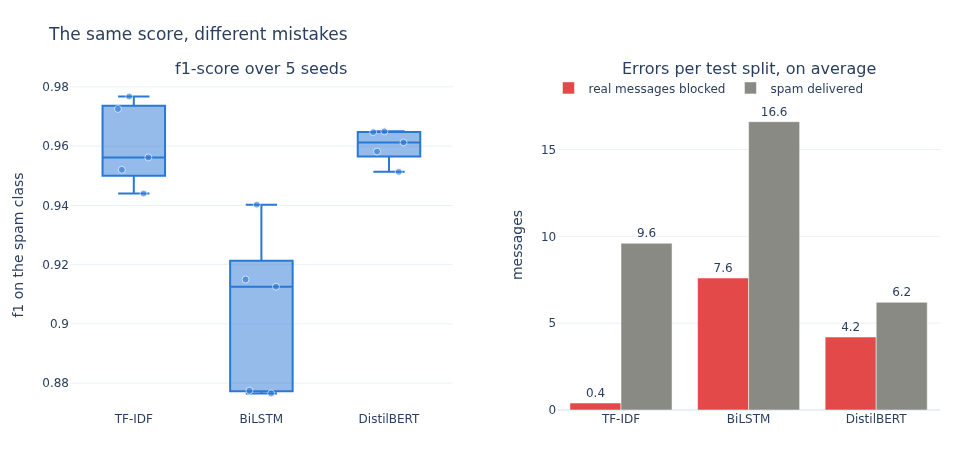

In [18]:
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12,
                    subplot_titles=('f1-score over 5 seeds', 'Errors per test split, on average'))
for name in ORDER:
    fig.add_trace(go.Box(y=seeds.loc[seeds['model'] == name, 'f1'], name=name.split(' ')[0],
                         marker_color=BLUE, line_width=2, boxpoints='all', jitter=0.6, pointpos=0,
                         marker=dict(size=7, opacity=0.6, line=dict(width=1, color='#fcfcfb')),
                         showlegend=False), row=1, col=1)
for column, color, label in [('false alarms', RED, 'real messages blocked'),
                             ('spam missed', GREY, 'spam delivered')]:
    fig.add_trace(go.Bar(x=[n.split(' ')[0] for n in ORDER], y=summary[column], name=label,
                         marker_color=color, text=summary[column].round(1),
                         textposition='outside', cliponaxis=False), row=1, col=2)
fig.update_yaxes(title='f1 on the spam class', row=1, col=1)
fig.update_yaxes(title='messages', row=1, col=2, range=[0, 19])
fig.update_layout(title='The same score, different mistakes', barmode='group',
                  legend=dict(orientation='h', y=1.02, x=0.55))
show(fig, '2_model_comparison', height=470)

**This is the finding of the project.**

The linear model and the fine-tuned transformer score the **same f1** — the gap between their means
is smaller than one standard deviation of either. Sixty-seven million parameters, a 268 MB
checkpoint and a GPU buy **nothing** on the metric the brief asks for.

What they buy is a different distribution of mistakes:

- **DistilBERT delivers fewer spams**, catching roughly three more per split.
- **The linear model raises almost no false alarms** — 0.4 per split against 4.2 for DistilBERT,
  ten times fewer.

And the network trained from scratch loses on both counts, with five times the seed-to-seed
variance. On 4 000 messages, learning a language from zero is not a strategy.

### 7.2 The false alarm is the expensive error, and it has a dial

A carrier that blocks a real message damages the service it sells; a spam that gets through is an
annoyance. So the comparison above is unfair to DistilBERT in one respect: its 4 false alarms come
from a threshold nobody chose — `argmax`, which is a 0.5 cut on a probability. The next cell asks
what the model looks like at every other cut.

In [19]:
@torch.no_grad()
def spam_probability(model, texts):
    model.eval()
    encoded = tokenizer(list(texts), truncation=True, max_length=64, padding='max_length',
                        return_tensors='pt')
    out = []
    for i in range(0, len(texts), 64):
        logits = model(encoded['input_ids'][i:i + 64].to(DEVICE),
                       encoded['attention_mask'][i:i + 64].to(DEVICE))
        out.append(torch.softmax(logits, dim=1)[:, 1].cpu())
    return torch.cat(out).numpy()


# Tuned on the validation split of section 5, never on the test set.
val_proba = spam_probability(bert, X_val)
precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
safe = thresholds[np.argmax(precision[:-1] >= 1.0)]      # the cheapest threshold with no false alarm
print(f'lowest threshold with zero false alarms on the validation split: {safe:.3f}\n')

test_proba = spam_probability(bert, X_test)
for label, cut in [('default (argmax)', 0.5), (f'no-false-alarm ({safe:.3f})', safe)]:
    p = (test_proba >= cut).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    print(f'{label:26s} f1 {f1_score(y_test, p):.4f}   precision {tp / (tp + fp):.3f}   '
          f'recall {tp / (tp + fn):.3f}   false alarms {fp}   spam missed {fn}')

lowest threshold with zero false alarms on the validation split: 0.964



default (argmax)           f1 0.9513   precision 0.934   recall 0.969   false alarms 9   spam missed 4
no-false-alarm (0.964)     f1 0.9644   precision 1.000   recall 0.931   false alarms 0   spam missed 9


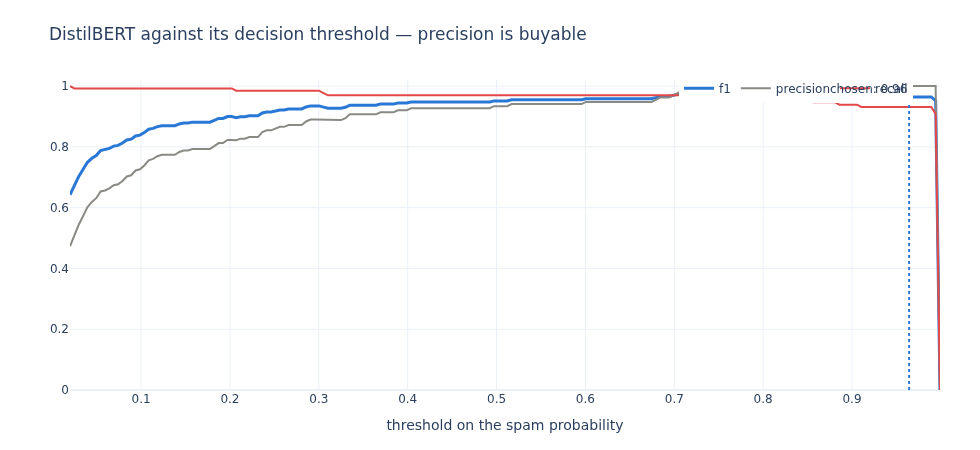

In [20]:
grid = np.linspace(0.02, 0.999, 200)
curves = {k: [] for k in ('f1', 'precision', 'recall')}
for cut in grid:
    p = (test_proba >= cut).astype(int)
    tp = int(((p == 1) & (y_test == 1)).sum())
    curves['f1'].append(f1_score(y_test, p))
    curves['precision'].append(tp / max(p.sum(), 1))
    curves['recall'].append(tp / int(y_test.sum()))

fig = go.Figure()
for key, color, width in [('f1', BLUE, 3), ('precision', GREY, 2), ('recall', RED, 2)]:
    fig.add_trace(go.Scatter(x=grid, y=curves[key], mode='lines', name=key,
                             line=dict(color=color, width=width)))
fig.add_vline(x=safe, line_dash='dot', line_color=BLUE,
              annotation_text=f'chosen: {safe:.2f}', annotation_position='top left')
fig.update_layout(title='DistilBERT against its decision threshold — precision is buyable',
                  xaxis=dict(title='threshold on the spam probability'),
                  yaxis=dict(title=None, range=[0, 1.02]),
                  legend=dict(orientation='h', y=1.02, x=0.7))
show(fig, '3_threshold', height=450)

The threshold settles the argument, and not in the transformer's favour.

Pushed to the point where it blocks nothing — a cut at **0.96**, chosen on the validation split —
DistilBERT lands on **exactly the reference model's numbers**: f1 0.9644, recall 0.931, nine spams
missed. Not close to them, the same ones. Its extra recall was not free intelligence, it was bought
from precision at a fixed rate, and once the false alarms are given back there is nothing left over.

> **The 67-million-parameter model is the linear model with extra steps** — unless AT&T is willing
> to withhold real messages, in which case it converts about one false alarm into one spam caught.

### 7.3 Where they disagree

In [21]:
# At the zero-false-alarm threshold, so the two models are compared at the same precision.
tuned_pred = (test_proba >= safe).astype(int)
compare = pd.DataFrame({'text': X_test.values, 'spam': y_test.values,
                        'reference': reference_pred, 'distilbert': tuned_pred})

print(f'spam DistilBERT catches and the linear model misses : '
      f'{int(((compare.spam == 1) & (compare.distilbert == 1) & (compare.reference == 0)).sum())}')
print(f'spam the linear model catches and DistilBERT misses : '
      f'{int(((compare.spam == 1) & (compare.reference == 1) & (compare.distilbert == 0)).sum())}')

print('\nspam that both models let through:')
for message in compare[(compare.spam == 1) & (compare.reference == 0) & (compare.distilbert == 0)].text.head(3):
    print(f'  - {message[:120]}')
print('\nspam only DistilBERT catches:')
for message in compare[(compare.spam == 1) & (compare.distilbert == 1) & (compare.reference == 0)].text.head(3):
    print(f'  - {message[:120]}')

spam DistilBERT catches and the linear model misses : 2
spam the linear model catches and DistilBERT misses : 2

spam that both models let through:
  - Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy bitch. How about we g
  - In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Green Day, B-Blue Day, C
  - RECPT 1/3. You have ordered a Ringtone. Your order is being processed...

spam only DistilBERT catches:
  - SMS. ac sun0819 posts HELLO:\You seem cool, wanted to say hi. HI!!!\" Stop? Send STOP to 62468"
  - ringtoneking 84484


Two spams each, in both directions: at equal precision the two models are not even wrong in
different places systematically — they trade a couple of borderline messages.

The spam **both** models let through is spam that does not look like spam: a quiz question, an
order confirmation, a joke. It carries no phone number, no price and no shouting — the message *is* the
bait, and the payload arrives in the reply. Neither a character n-gram nor a transformer can see
that from one message in isolation; it would take the conversation, or the number that sent it.

## 8. What AT&T should deploy

In [22]:
sample = list(X_test[:200])
t0 = time.time()
for message in sample:
    reference.predict([message])
reference_ms = (time.time() - t0) / len(sample) * 1000

encoded = tokenizer(sample, truncation=True, max_length=64, padding='max_length', return_tensors='pt')
with torch.no_grad():
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for i in range(len(sample)):
        bert(encoded['input_ids'][i:i + 1].to(DEVICE), encoded['attention_mask'][i:i + 1].to(DEVICE))
    if DEVICE == 'cuda':
        torch.cuda.synchronize()
    bert_ms = (time.time() - t0) / len(sample) * 1000

    bert.to('cpu')
    t0 = time.time()
    for i in range(50):
        bert(encoded['input_ids'][i:i + 1], encoded['attention_mask'][i:i + 1])
    bert_cpu_ms = (time.time() - t0) / 50 * 1000
    bert.to(DEVICE)

import pickle
print(f'{"model":24s} {"f1":>7s} {"size":>9s} {"one SMS":>12s}')
print(f'{"TF-IDF + linear SVM":24s} {summary.loc["TF-IDF + linear SVM", "f1 mean"]:7.4f} '
      f'{len(pickle.dumps(reference)) / 1e6:7.1f} MB {reference_ms:9.2f} ms  (CPU)')
print(f'{"DistilBERT fine-tuned":24s} {summary.loc["DistilBERT fine-tuned", "f1 mean"]:7.4f} '
      f'{sum(p.numel() for p in bert.parameters()) * 4 / 1e6:7.0f} MB {bert_ms:9.2f} ms  ({DEVICE})'
      f' / {bert_cpu_ms:.0f} ms (CPU)')

model                         f1      size      one SMS
TF-IDF + linear SVM       0.9603     0.9 MB      0.61 ms  (CPU)
DistilBERT fine-tuned     0.9601     268 MB      7.73 ms  (cuda) / 25 ms (CPU)


**1. Deploy the linear model, and state the performance plainly: f1 0.96 on messages it has never
seen, with essentially no legitimate message blocked.** It trains in under a second, weighs a
megabyte, scores an SMS in about a millisecond on one CPU core, and needs no accelerator anywhere
in the stack. At carrier volume that is the whole argument.

**2. The transformer earns its place only if AT&T will pay for it in false alarms.** At `argmax` it
delivers 3 fewer spams per split and withholds 4 more real messages; forced to block nothing, it
reproduces the reference model's score exactly. It also costs **16 ms per message on a CPU** — thirty
times the reference — and 268 MB of weights. If it is deployed at all, it belongs behind the cheap
model, scoring only the messages the linear one is unsure about.

**3. The deep learning result that matters is a negative one, and it is worth stating in the
review: on 4 000 messages, a network trained from scratch is beaten by TF-IDF.** Six points of f1
separate them. Every point DistilBERT adds comes from the 3 billion words it read before it ever
saw an SMS — the architecture is not what makes the difference here, the pretraining is.

**4. What would actually move the score is not a bigger model.** Both models fail on the same
messages: conversational bait with no number and no price. That failure is not visible in the text
of one SMS, so it will not be fixed by reading that text harder. It needs what this file does not
contain — the sender, the time, whether the same text went to ten thousand handsets in one minute.
The next point of f1 is a data question, not a model question.